In the name of God

# **Machine Learning Homework: Regression Analysis and Nonlinear Modeling**

Seyed Mani Mirshabani 
810801080

با توجه به اینکه قصد دارم در گیتهابم قرار بدم و بعدا به عنوان رزومه باشه با اجازه شما متن های نوتبوک رو به انگلیسی مینویسم (برای این کار از هوش مصنوعی استفاده نمیکنم و هرچیزی که متوجه شده باشم رو خودم به انگلیسی مینویسم برای همین پیشاپیش بابت اشتباهات مربوط به انگلیسی معذرت میخوام)

## **Part 1: Manual Regression Calculations**  

### **Step 1: Simple Linear Regression**  

Given the following data points for `GrLivArea` (x) and `SalePrice` (y):  

| x (GrLivArea) | y (SalePrice) |
|---------------|---------------|
| 1500          | 200000        |
| 1600          | 210000        |
| 1700          | 220000        |
| 1800          | 230000        |
| 1900          | 240000        |

#### Tasks:
- Compute the mean of x and y.
- Calculate the slope (w) and intercept (b) using the least squares formula.
- Write the regression equation: `y = wx + b`.
- Predict the price for a house with `GrLivArea = 2000`.


![1.1.1](1.jpg)

![1.1.2](2.jpg)

### **Step 2: Polynomial Regression (Manual Expansion)**  

Using the same dataset, expand x to include a quadratic term: `x²`.  

| x | x² |
|----|----|
|1500|2250000|
|1600|2560000|
|1700|2890000|
|1800|3240000|
|1900|3610000|

#### Tasks:
- Fit a second-degree polynomial regression manually using matrix notation.
- Solve for coefficients using normal equations.
- Compare predictions for `x = 2000` using linear vs. polynomial models.


![1.2.1](3.jpg)

![1.2.2](3.jpg)

## **Part 2: Python Implementation**  

### **Step 1: Load and Explore the Ames Housing Dataset**  

- Load the dataset from `https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch09/AmesHousing.txt`
- Display basic statistics and correlation matrix.
- Visualize `GrLivArea` vs `SalePrice` using scatter plots.

For this section we will go a step beyond what is requested by checking the missing values and performing some basic EDA. The steps we will take will be as follows:

1. Loading teh data.
2. Getting some quick info from the data.
3. Looking at correlations
4. Drawing the scatter plot
5. Looking at the distribution
6. Checking for outliers

#### 2.1.1. Loading the data

In this section we will load the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 5)

url = "https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch09/AmesHousing.txt"

try:
    df = pd.read_csv(url, sep='\t', low_memory=False)
except Exception:
    df = pd.read_csv(url, sep=',', low_memory=False)

print("Loaded dataset shape:", df.shape)

Loaded dataset shape: (2930, 82)


#### 2.1.2. Getting some quick information about the data

In this section we get an overall idea by looking at the head, info, describe and missing values of the dataset.

In [2]:
display(df.head(8))
print("\n--- Info ---")
df.info()

print("\n--- Numeric summary (describe) ---")
display(df.describe().T)

missing = df.isna().sum().sort_values(ascending=False)
print("\nTop missing-value columns (if any):")
display(missing[missing > 0].head(20))

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
5,6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
6,7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
7,8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500



--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  

,count,mean,std,min,25%,50%,75%,max
Order,2930.0,1.465500e+03,8.459625e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MS SubClass,2930.0,5.738737e+01,4.263802e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2440.0,6.922459e+01,2.336533e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2930.0,1.014792e+04,7.880018e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
Overall Qual,2930.0,6.094881e+00,1.411026e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2930.0,5.563140e+00,1.111537e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2930.0,1.971356e+03,3.024536e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2930.0,1.984267e+03,2.086029e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2907.0,1.018968e+02,1.791126e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03



Top missing-value columns (if any):


Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
dtype: int64

As we can see, we have quite a few missing values and we need to do something about them.

For handling these missing values we will drop the columns with too many missing values (400+) and impute the values on the rest (using the median for numerical values to avoid being effected by outliers and replacing the categorical values with 'Missing')

In [3]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

threshold = 400

missing = df.isna().sum().sort_values(ascending=False)
print("Top missing counts:")
print(missing.head(30))

drop_cols = missing[missing > threshold].index.tolist()
print("\nDropping columns with >", threshold, "missing values (count:):", len(drop_cols))
print(drop_cols)
df2 = df.drop(columns=drop_cols).copy()

indicator_cols = []
for c in df2.columns:
    if df2[c].isna().sum() > 0:
        ind_name = c + "_missing"
        df2[ind_name] = df2[c].isna().astype(int)
        indicator_cols.append(ind_name)
print("\nCreated missing-indicator columns for:", len(indicator_cols))

numeric_cols = df2.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df2.select_dtypes(include=['object', 'category']).columns.tolist()
print("\nNumeric cols count:", len(numeric_cols))
print("Categorical cols count:", len(cat_cols))

num_imputer = SimpleImputer(strategy='median')
df_num = pd.DataFrame(num_imputer.fit_transform(df2[numeric_cols]),
                      columns=numeric_cols, index=df2.index)

cat_imputer = SimpleImputer(strategy='constant', fill_value='Missing')
if len(cat_cols) > 0:
    df_cat = pd.DataFrame(cat_imputer.fit_transform(df2[cat_cols]),
                          columns=cat_cols, index=df2.index)
else:
    df_cat = pd.DataFrame(index=df2.index)

df_clean = pd.concat([df_num, df_cat], axis=1)

print("\nAfter imputation, missing per column (should be 0):")
print(df_clean.isna().sum().sort_values(ascending=False).head(10))

print("\nCleaned dataframe shape:", df_clean.shape)
display(df_clean.head())

Top missing counts:
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
Total Bsmt SF        1
BsmtFin SF 1         1
BsmtFin SF 2         1
Garage Area          1
Garage Cars          1
Bsmt Unf SF          1
Electrical           1
Lot Shape            0
Street               0
Lot Area             0
dtype: int64

Dropping columns with > 400 missing values (count:): 7
['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Mas Vnr Type', 'Fireplace Qu', 'Lot Frontage']

Created missing-indicator columns for: 20

Numeric cols count: 58
Categorical cols count: 37

After imputation, missing per co

,Order,PID,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Electrical,Kitchen Qual,Functional,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition
0,1.0,526301100.0,20.0,31770.0,6.0,5.0,1960.0,1960.0,112.0,639.0,...,SBrkr,TA,Typ,Attchd,Fin,TA,TA,P,WD,Normal
1,2.0,526350040.0,20.0,11622.0,5.0,6.0,1961.0,1961.0,0.0,468.0,...,SBrkr,TA,Typ,Attchd,Unf,TA,TA,Y,WD,Normal
2,3.0,526351010.0,20.0,14267.0,6.0,6.0,1958.0,1958.0,108.0,923.0,...,SBrkr,Gd,Typ,Attchd,Unf,TA,TA,Y,WD,Normal
3,4.0,526353030.0,20.0,11160.0,7.0,5.0,1968.0,1968.0,0.0,1065.0,...,SBrkr,Ex,Typ,Attchd,Fin,TA,TA,Y,WD,Normal
4,5.0,527105010.0,60.0,13830.0,5.0,5.0,1997.0,1998.0,0.0,791.0,...,SBrkr,TA,Typ,Attchd,Fin,TA,TA,Y,WD,Normal


#### 2.1.3. Column correlation

In this section we will calculate the correlation of different variables with our target variable (sale price) and show a heatmap of the correlations between variables that make the most sense.

Top correlations with SalePrice:


SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Lot Frontage      0.357318
Wood Deck SF      0.327143
Open Porch SF     0.312951
Half Bath         0.285056
Bsmt Full Bath    0.276050
2nd Flr SF        0.269373
Lot Area          0.266549
Bsmt Unf SF       0.182855
Bedroom AbvGr     0.143913
Screen Porch      0.112151
Pool Area         0.068403
Mo Sold           0.035259
3Ssn Porch        0.032225
BsmtFin SF 2      0.005891
Misc Val         -0.015691
Name: SalePrice, dtype: float64

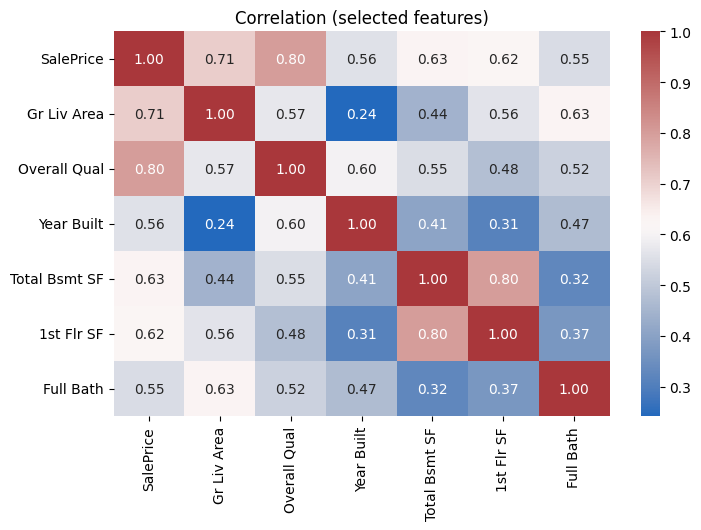

In [4]:
num_df = df.select_dtypes(include=[np.number]).copy()

corr = num_df.corr()

if 'SalePrice' in corr:
    sale_corr = corr['SalePrice'].sort_values(ascending=False)
    print("Top correlations with SalePrice:")
    display(sale_corr.head(30))

selected = ['SalePrice', 'Gr Liv Area', 'Overall Qual', 'Year Built', 'Total Bsmt SF', '1st Flr SF', 'Full Bath']
selected = [c for c in selected if c in num_df.columns]
sns.heatmap(num_df[selected].corr(), annot=True, fmt=".2f", cmap='vlag')
plt.title("Correlation (selected features)")
plt.show()

As we can see, there are quite a few variables with high correlation with our target variable such as Overall Qual, Gr Liv Area and Garage Cars.

We can also see that there isn't a very strong correlation between other variables (with a few exceptions such as 1st Flr SF with Total Bsmt SF) which is good as too much correlation would result in a lower performance for our model.

#### 2.1.4. Scatter plot

In this section we will plot the scatter plot of Gr Liv Area vs SalePrice to see their relationship, we will also fit a linear regression line to examine a linear relationship and LOWESS to see nonlinearity.

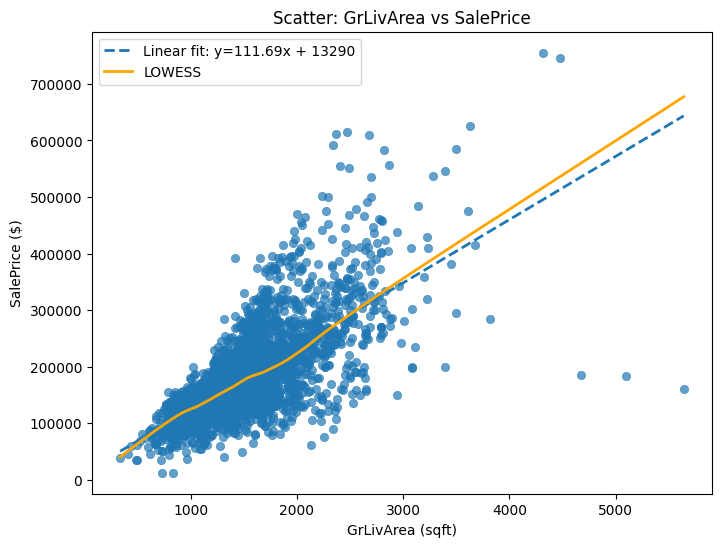

In [5]:
from statsmodels.nonparametric.smoothers_lowess import lowess

x = 'Gr Liv Area'
y = 'SalePrice'
if x not in df.columns or y not in df.columns:
    raise ValueError(f"Columns {x} or {y} not found in dataframe. Available numeric cols: {list(num_df.columns)[:30]}")

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x=x, y=y, alpha=0.7, edgecolor=None)

mask = df[[x,y]].dropna()
coeffs = np.polyfit(mask[x], mask[y], deg=1)
x_line = np.linspace(mask[x].min(), mask[x].max(), 100)
y_line = np.polyval(coeffs, x_line)
plt.plot(x_line, y_line, linestyle='--', linewidth=2, label=f'Linear fit: y={coeffs[0]:.2f}x + {coeffs[1]:.0f}')


low = lowess(mask[y], mask[x], frac=0.3)
plt.plot(low[:,0], low[:,1], color='orange', linewidth=2, label='LOWESS')


plt.xlabel('GrLivArea (sqft)')
plt.ylabel('SalePrice ($)')
plt.title('Scatter: GrLivArea vs SalePrice')
plt.legend()
plt.show()

We can see that there is a relation between these two variable but it's clearly not enough to predict the values and we need the rest of the columns too.

#### 2.1.5. Distribution

In this section we will plot the histogram and KDE for SalePrice and compute skewness for it.

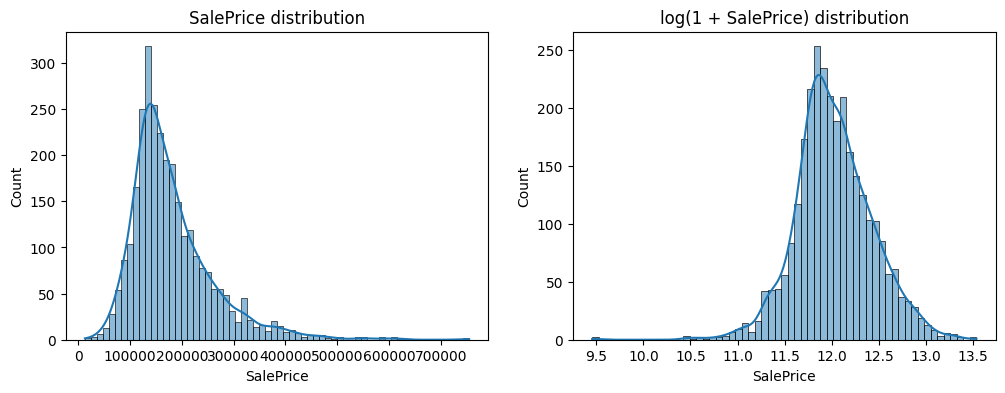

Skewness - original SalePrice: 1.744; log(1+SalePrice): -0.015


In [6]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df['SalePrice'].dropna(), kde=True)
plt.title('SalePrice distribution')

plt.subplot(1,2,2)
sns.histplot(np.log1p(df['SalePrice'].dropna()), kde=True)
plt.title('log(1 + SalePrice) distribution')

plt.show()

skew_orig = df['SalePrice'].dropna().skew()
skew_log = np.log1p(df['SalePrice'].dropna()).skew()
print(f"Skewness - original SalePrice: {skew_orig:.3f}; log(1+SalePrice): {skew_log:.3f}")

#### 2.1.6. Outlier check

In this section we will use the iqr to check for potential outliers.

In [7]:
def iqr_outliers(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k*iqr
    upper = q3 + k*iqr
    return (series < lower) | (series > upper)

for col in ['Gr Liv Area', 'SalePrice']:
    if col in df.columns:
        mask_out = iqr_outliers(df[col].dropna())
        print(f"{col}: {mask_out.sum()} outliers out of {len(df[col].dropna())}")

outliers_mask = iqr_outliers(df['Gr Liv Area']) | iqr_outliers(df['SalePrice'])
display(df.loc[outliers_mask].sort_values('SalePrice').head(10))

Gr Liv Area: 75 outliers out of 2930
SalePrice: 137 outliers out of 2930


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1182,1183,533350090,60,RL,NaN,24572,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2008,WD,Family,150000
1498,1499,908154235,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
2180,2181,908154195,20,RL,128.0,39290,Pave,NaN,IR1,Bnk,...,0,NaN,NaN,Elev,17000,10,2007,New,Partial,183850
2181,2182,908154205,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
909,910,909179020,75,RL,102.0,15863,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,8,2009,WD,Normal,197000
2194,2195,909176080,190,RH,60.0,10896,Pave,Pave,Reg,Bnk,...,0,NaN,NaN,NaN,0,3,2007,WD,Abnorml,200000
2045,2046,904101070,50,RL,138.0,18030,Pave,NaN,IR1,Bnk,...,0,NaN,MnPrv,NaN,0,3,2007,WD,Normal,200500
2570,2571,535150300,75,RL,174.0,25419,Pave,NaN,Reg,Lvl,...,512,Ex,GdPrv,NaN,0,3,2006,WD,Abnorml,235000
160,161,535425010,80,RL,96.0,11275,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,242000
376,377,527353060,60,RL,NaN,12388,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,8,2009,WD,Normal,249000


### **Step 2: Linear Regression with Scikit-Learn**  

- Fit a linear regression model using `GrLivArea` to predict `SalePrice`.
- Print coefficients and intercept.
- Evaluate model using MAE and R².

For this section, we will take it one step further. We will train a simple model as described, then we will train a model with all the features and PCA. For the simple model we will also show the coefficients.

Finally we will evaluate all the models with MAE and R2.

#### 2.2.1. Simple linear regression (Gr Liv Area only)

Here we will fit the simple regression version.

In [8]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

df_clean = df.copy()

df = df_clean.copy()

assert 'SalePrice' in df.columns, "df_clean must contain 'SalePrice'."

X_full = df.drop(columns=['SalePrice'])
y_full = df['SalePrice'].values

X_train_full, X_test_full, y_train, y_test = train_test_split(X_full, y_full, test_size=0.20, random_state=42)

X_train_simple = X_train_full[['Gr Liv Area']].copy()
X_test_simple  = X_test_full[['Gr Liv Area']].copy()

lr_simple = LinearRegression()
mask_train = X_train_simple['Gr Liv Area'].notna()
mask_test  = X_test_simple['Gr Liv Area'].notna()

lr_simple.fit(X_train_simple[mask_train], y_train[mask_train])

y_pred_simple = lr_simple.predict(X_test_simple[mask_test])

mae_simple = mean_absolute_error(y_test[mask_test], y_pred_simple)
r2_simple  = r2_score(y_test[mask_test], y_pred_simple)

print("SIMPLE MODEL (Gr Liv Area only)")
print("-" * 40)
print(f"Slope (dollars per sqft): {lr_simple.coef_[0]:.2f}")
print(f"Intercept: {lr_simple.intercept_:.2f}")
print(f"Test MAE: {mae_simple:.2f}")
print(f"Test R^2: {r2_simple:.4f}")

SIMPLE MODEL (Gr Liv Area only)
----------------------------------------
Slope (dollars per sqft): 106.73
Intercept: 19250.56
Test MAE: 41365.51
Test R^2: 0.5234


As we can see, the model has been trained successfully but the results aren't ideal (which we saw in the section where we drew the scatter plot and fitted a regression model to it!)

#### 2.2.2. Regression with more features

In this section we will build a pipeline that scales the numerical features and one hot encodes the categorical features and performs a PCA on them before fitting a linear regression to it to see if adding other features would result in a better performance or not.

In [9]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

numeric_cols = X_train_full.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'SalePrice']
cat_cols = X_train_full.select_dtypes(include=['object', 'category']).columns.tolist()

print("Num numeric cols:", len(numeric_cols))
print("Num categorical cols:", len(cat_cols))

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='drop', verbose_feature_names_out=False)

pca_pipeline = Pipeline(steps=[
    ('preproc', preprocessor),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('lr', LinearRegression())
])

pca_pipeline.fit(X_train_full, y_train)

y_pred_pca = pca_pipeline.predict(X_test_full)

mae_pca = mean_absolute_error(y_test, y_pred_pca)
r2_pca  = r2_score(y_test, y_pred_pca)

n_components = pca_pipeline.named_steps['pca'].n_components_
print("\nPCA + LinearRegression model")
print("-" * 40)
print(f"PCA components kept (95% variance): {n_components}")
print(f"Test MAE: {mae_pca:.2f}")
print(f"Test R^2: {r2_pca:.4f}")

Num numeric cols: 38
Num categorical cols: 43


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

We can clearly see a noticeable performance gain here!

#### 2.2.3. Comparison

Here we will compare the results.

In [ ]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

common_mask = X_test_full['Gr Liv Area'].notna()
y_test_common = y_test[common_mask]
y_pred_simple_common = lr_simple.predict(X_test_simple[common_mask])

y_pred_pca_common = pca_pipeline.predict(X_test_full[common_mask])

results = pd.DataFrame({
    'model': ['Simple (Gr Liv Area)', 'PCA(95%) + Linear'],
    'MAE': [
        mean_absolute_error(y_test_common, y_pred_simple_common),
        mean_absolute_error(y_test_common, y_pred_pca_common)
    ],
    'R2': [
        r2_score(y_test_common, y_pred_simple_common),
        r2_score(y_test_common, y_pred_pca_common)
    ]
})

print("Comparison on test rows with Gr Liv Area present:")
display(results)

median_gr = X_train_full['Gr Liv Area'].median()
X_test_simple_imputed = X_test_full[['Gr Liv Area']].fillna(median_gr)
y_pred_simple_imputed = lr_simple.predict(X_test_simple_imputed)

results_all = pd.DataFrame({
    'model': ['Simple (Gr Liv Area) imputed', 'PCA(95%) + Linear (all test rows)'],
    'MAE': [
        mean_absolute_error(y_test, y_pred_simple_imputed),
        mean_absolute_error(y_test, y_pred_pca)
    ],
    'R2': [
        r2_score(y_test, y_pred_simple_imputed),
        r2_score(y_test, y_pred_pca)
    ]
})
print("\nComparison on full test set (simple model used median imputation for missing Gr Liv Area):")
display(results_all)

best_model_idx = results['MAE'].idxmin()
best_model = results.loc[best_model_idx, 'model']
print(f"\nSummary: On the common test subset, the model with lower MAE is: {best_model}")

Comparison on test rows with Gr Liv Area present:


,model,MAE,R2
0,Simple (Gr Liv Area),41365.511318,0.523397
1,PCA(95%) + Linear,18446.742272,0.878597



Comparison on full test set (simple model used median imputation for missing Gr Liv Area):


,model,MAE,R2
0,Simple (Gr Liv Area) imputed,41365.511318,0.523397
1,PCA(95%) + Linear (all test rows),18446.742272,0.878597



Summary: On the common test subset, the model with lower MAE is: PCA(95%) + Linear


As we can see the model with all the features had a noticeably better performance with a R2 score of 0.87 compared to 0.52

### **Step 3: Polynomial Regression**  

- Use `PolynomialFeatures` to add quadratic terms.
- Fit and evaluate the polynomial model.
- Compare performance with linear regression.


Similar to the last step, we will go one further by training two models, one with only the single feature and one with all the features and PCA (both will use polynomial regression)

#### 2.3.1. Single feature

Let's train the polynomial regression on a single feature first

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

df = df_clean.copy()

X_train_full, X_test_full, y_train, y_test

X_train_simple = X_train_full[['Gr Liv Area']].copy()
X_test_simple  = X_test_full[['Gr Liv Area']].copy()

mask_train = X_train_simple['Gr Liv Area'].notna()
mask_test  = X_test_simple['Gr Liv Area'].notna()

poly = PolynomialFeatures(degree=2, include_bias=True) 
X_train_poly = poly.fit_transform(X_train_simple[mask_train].values.reshape(-1,1))
X_test_poly  = poly.transform(X_test_simple[mask_test].values.reshape(-1,1))

lr_poly_simple = LinearRegression()
lr_poly_simple.fit(X_train_poly, y_train[mask_train])

feat_names = poly.get_feature_names_out(['Gr Liv Area'])

print("Polynomial features (simple) names:", feat_names)

coefs = np.concatenate(([lr_poly_simple.intercept_], lr_poly_simple.coef_[1:])) \
        if lr_poly_simple.coef_.shape[0] == X_train_poly.shape[1] else np.concatenate(([lr_poly_simple.intercept_], lr_poly_simple.coef_))

print("\nSIMPLE POLYNOMIAL MODEL (Gr Liv Area degree=2)")
print("-" * 50)
print(f"Intercept: {lr_poly_simple.intercept_:.2f}")
for name, coef in zip(feat_names[1:], lr_poly_simple.coef_[1:]):  # skip first because intercept is separate
    print(f"Coef for {name}: {coef:.6f}")

y_pred_simple_poly = lr_poly_simple.predict(X_test_poly)
mae_simple_poly = mean_absolute_error(y_test[mask_test], y_pred_simple_poly)
r2_simple_poly = r2_score(y_test[mask_test], y_pred_simple_poly)

print("\nTest metrics (only rows with Gr Liv Area present):")
print(f"MAE (Poly Gr Liv Area): {mae_simple_poly:.2f}")
print(f"R^2  (Poly Gr Liv Area): {r2_simple_poly:.4f}")

Polynomial features (simple) names: ['1' 'Gr Liv Area' 'Gr Liv Area^2']

SIMPLE POLYNOMIAL MODEL (Gr Liv Area degree=2)
--------------------------------------------------
Intercept: -11858.44
Coef for Gr Liv Area: 145.077607
Coef for Gr Liv Area^2: -0.010527

Test metrics (only rows with Gr Liv Area present):
MAE (Poly Gr Liv Area): 41445.14
R^2  (Poly Gr Liv Area): 0.5322


We can see the results are rather similar to the one without polynomial (we will compare all the models in the last section)

#### 2.3.2. Multiple feature

Here we will use all the features but we only add teh polynomial term for the numeric values as adding them for the one hot encoded features would result in too many variables and wouldn't really be helpful.

Another important thing to note here is I originally tried the pipeline with PCA but the results were quite terrible (R2 score of 0.1) and I'm guessing this is because of the very high correlations when we add the x^2 terms, so I have only left the code that doesn't have PCA and performs noticeably better.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

numeric_cols = X_train_full.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'SalePrice']
cat_cols = X_train_full.select_dtypes(include=['object', 'category']).columns.tolist()

print("Number of numeric cols to expand:", len(numeric_cols))
print("Number of categorical cols to one-hot:", len(cat_cols))

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, cat_cols)
], remainder='drop', verbose_feature_names_out=False)

poly_pca_pipeline = Pipeline(steps=[
    ('preproc', preprocessor),
    ('lr', LinearRegression())
])

poly_pca_pipeline.fit(X_train_full, y_train)

y_pred_poly_all = poly_pca_pipeline.predict(X_test_full)
mae_poly_all = mean_absolute_error(y_test, y_pred_poly_all)
r2_poly_all = r2_score(y_test, y_pred_poly_all)

print("\nPolynomial (numeric degree=2) + LinearRegression")
print("-" * 60)
print(f"Test MAE: {mae_poly_all:.2f}")
print(f"Test R^2: {r2_poly_all:.4f}")

Number of numeric cols to expand: 57
Number of categorical cols to one-hot: 37

Polynomial (numeric degree=2) + LinearRegression
------------------------------------------------------------
Test MAE: 21330.87
Test R^2: 0.7236


Again, we see a noticeable boost over only using a single variable

#### 2.3.3. Comparison

Now let's compare all four models